# 02 — Probe Development

Interactive development of probes on a small model.
Start here to verify the activation extraction and probe training pipeline
before running full-scale experiments.

**Prerequisite:** run `01_data_exploration.ipynb` first to validate graph extraction.

In [3]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.models.loader import ModelConfig, ModelLoader
from src.models.hooks import extract_hidden_states
from src.data.generator import SyntheticCodeGenerator, SyntheticSpec
from src.graphs.dfg_extractor import DefUseExtractor
from src.probes.base import LinearProbe, ProbeConfig, cross_validate_probe
from src.probes.defuse import DefUseEdgeProbe, DefUseExample
from src.analysis.visualization import plot_layer_curves

import pandas as pd

## 1. Load a small model

In [4]:
import torch

MODEL_NAME = 'deepseek-coder-1.3b'

device = (
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Using device: {device}')

cfg = ModelConfig.from_registry(MODEL_NAME, device=device)
print(f'Model: {cfg.hf_id}')
print(f'Layers: {cfg.n_layers}, d_model: {cfg.d_model}')
print(f'Probe layers: {cfg.probe_layers}')

loader = ModelLoader(cfg)
print('Loading tokenizer...')
tokenizer = loader.tokenizer
print('Loading model...')
model = loader.model
print('Done.')


Using device: mps
Model: deepseek-ai/deepseek-coder-1.3b-base
Layers: 24, d_model: 2048
Probe layers: [0, 3, 7, 11, 15, 19, 23]
Loading tokenizer...
Loading model...


Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Done.


## 2. Extract activations from a single example

In [5]:
source = """
def f(x):
    a = x + 1
    b = a * 2
    c = b - a
    return c
""".strip()

inputs = tokenizer(source, return_tensors='pt', truncation=True, max_length=256)
token_strs = loader.token_strings(inputs['input_ids'])

print(f'Token count: {len(token_strs)}')
print(f'Tokens: {token_strs}')


Token count: 22
Tokens: ['de', 'ff', '(', 'x', '):', 'a', '=', 'x', '+', '1', 'b', '=', 'a', '*', '2', 'c', '=', 'b', '-', 'are', 'turn', 'c']


In [6]:
PROBE_LAYERS = cfg.probe_layers

with torch.no_grad():
    cache = extract_hidden_states(
        model,
        inputs['input_ids'].to(cfg.device),
        layer_indices=PROBE_LAYERS,
    )

print(cache)
hs = cache.all_hidden_states()   # (n_probe_layers, seq_len, d_model)
print(f"Hidden states shape: {hs.shape}")

ActivationCache(layers=[0, 3, 7, 11, 15, 19, 23], shape=(22, 2048))
Hidden states shape: torch.Size([7, 22, 2048])


## 3. Ground-truth def-use edges

In [7]:
dfg_extractor = DefUseExtractor()
dfg = dfg_extractor.extract(source)

print(f"Def-use edges ({len(dfg)}):")
for edge in dfg.edges:
    print(f"  '{edge.definition.name}' def@L{edge.definition.line} → use@L{edge.use.line}")

Def-use edges (5):
  'x' def@L1 → use@L2
  'a' def@L2 → use@L3
  'b' def@L3 → use@L4
  'a' def@L2 → use@L4
  'c' def@L4 → use@L5


## 4. Build probe dataset across layers

In [8]:
from collections import defaultdict
import random
rng = random.Random(42)

# Map each token name to all positions it appears at
name_positions = defaultdict(list)
for i, t in enumerate(token_strs):
    name_positions[t.strip()].append(i)

# Build positive pairs from DFG edges: any (def_pos, use_pos) pair
# where the token name matches and positions differ
positive_pairs = set()
for edge in dfg.edges:
    for di in name_positions.get(edge.definition.name, []):
        for ui in name_positions.get(edge.use.name, []):
            if di != ui:
                positive_pairs.add((di, ui))

print(f'Found {len(positive_pairs)} positive def-use pairs')

# Build examples per layer
all_examples = []
n_tokens = len(token_strs)

for layer_pos, layer_idx in enumerate(PROBE_LAYERS):
    for (di, ui) in positive_pairs:
        h_i = hs[layer_pos, di].numpy()
        h_j = hs[layer_pos, ui].numpy()
        all_examples.append(DefUseExample(
            hidden_i=h_i, hidden_j=h_j,
            has_edge=True, layer=layer_idx,
            pos_i=di, pos_j=ui, distance=abs(ui - di)
        ))
    
    # Negatives: random pairs not in positive set
    for _ in range(len(positive_pairs) * 3):
        i, j = rng.randint(0, n_tokens-1), rng.randint(0, n_tokens-1)
        if i != j and (i, j) not in positive_pairs:
            h_i = hs[layer_pos, i].numpy()
            h_j = hs[layer_pos, j].numpy()
            all_examples.append(DefUseExample(
                hidden_i=h_i, hidden_j=h_j,
                has_edge=False, layer=layer_idx,
                pos_i=i, pos_j=j, distance=abs(j-i)
            ))

print(f'Total examples (all layers): {len(all_examples)}')


Found 8 positive def-use pairs
Total examples (all layers): 215


## 5. Train and evaluate probes across layers

In [9]:
probe = DefUseEdgeProbe(config=ProbeConfig(cv_folds=5, run_selectivity_control=True))

results = []
for layer in PROBE_LAYERS:
    r = probe.run(all_examples, layer)
    results.append(r)
    print(f"  Layer {layer:2d}: acc={r.accuracy:.3f}, sel={r.selectivity:.3f}, ctrl={r.control_accuracy:.3f}")

df = pd.DataFrame([r.to_dict() for r in results])
df['task'] = 'defuse_edge'
df.head()

  Layer  0: acc=0.967, sel=0.267, ctrl=0.700
  Layer  3: acc=0.695, sel=0.005, ctrl=0.690
  Layer  7: acc=0.633, sel=-0.095, ctrl=0.729
  Layer 11: acc=0.710, sel=0.057, ctrl=0.652
  Layer 15: acc=0.643, sel=0.095, ctrl=0.548
  Layer 19: acc=0.700, sel=0.000, ctrl=0.700
  Layer 23: acc=0.660, sel=-0.033, ctrl=0.693


,layer,task,accuracy,f1,auc,control_accuracy,selectivity,n_train,n_test
0,0,defuse_edge,0.966667,0.965714,0.975,0.700000,0.266667,30,0
1,3,defuse_edge,0.695238,0.550000,0.580,0.690476,0.004762,32,0
2,7,defuse_edge,0.633333,0.448283,0.540,0.728571,-0.095238,32,0
3,11,defuse_edge,0.709524,0.556667,0.665,0.652381,0.057143,31,0
4,15,defuse_edge,0.642857,0.462381,0.740,0.547619,0.095238,31,0


## 6. Plot results

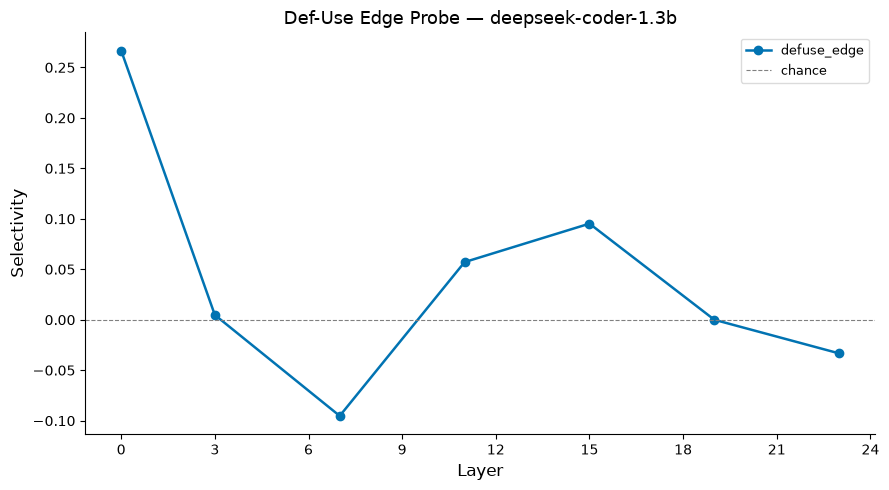

In [10]:
fig = plot_layer_curves(
    df,
    metric='selectivity',
    title=f'Def-Use Edge Probe — {MODEL_NAME}'
)
plt.show()

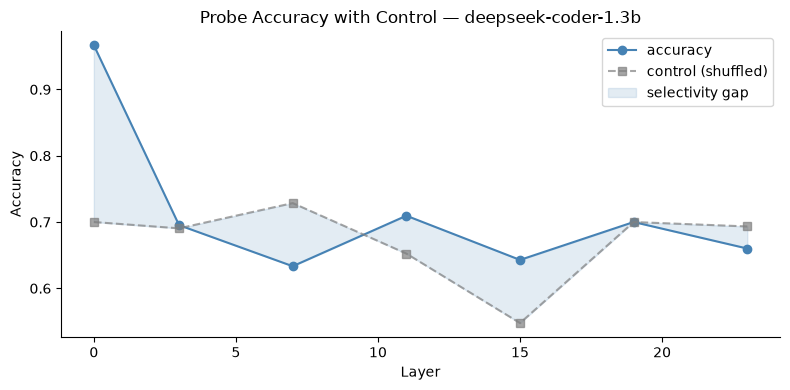

In [11]:
# Also plot raw accuracy vs control
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df['layer'], df['accuracy'], 'o-', label='accuracy', color='steelblue')
ax.plot(df['layer'], df['control_accuracy'], 's--', label='control (shuffled)', color='gray', alpha=0.7)
ax.fill_between(df['layer'], df['control_accuracy'], df['accuracy'],
                alpha=0.15, color='steelblue', label='selectivity gap')
ax.set_xlabel('Layer')
ax.set_ylabel('Accuracy')
ax.set_title(f'Probe Accuracy with Control — {MODEL_NAME}')
ax.legend()
import seaborn as sns; sns.despine(ax=ax)
plt.tight_layout()
plt.show()